# Football JEPA — Action Spotting Probe

**Three milestones in one notebook:**
1. **Dataloader** — clips of ResNET features centered on events + background negatives
2. **Attentive probe** — 4-layer transformer + cross-attention read-out (V-JEPA protocol)
3. **Spotting** — sliding window inference, peak-picking, Average-mAP

**Before running:** set your SoccerNet NDA password in the Config cell below.

## 0. Setup

In [1]:
!pip install SoccerNet scipy scikit-learn matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 58.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 81.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 10.5 MB/s eta 0:00:00


In [2]:
import os

# ── Configuration — edit these ────────────────────────────────────────────────
SOCCERNET_PASSWORD = "s0cc3rn3t"   # your NDA password
DATA_DIR           = "/content/soccernet"   # where data is stored on Colab
N_TRAIN_GAMES      = 20
N_VALID_GAMES      = 5
EPOCHS             = 30
BATCH_SIZE         = 128
LR                 = 1e-3
QUERY_EVENT        = "Corner"               # event class to demo-query in M3
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs("/content/results", exist_ok=True)

In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 1. Download data

In [4]:
import google_measurement_protocol
google_measurement_protocol.report = lambda *a, **kw: []  # suppress GA telemetry

from SoccerNet.Downloader import SoccerNetDownloader
from SoccerNet.utils import getListGames
from pathlib import Path

d = SoccerNetDownloader(DATA_DIR)
d.password = SOCCERNET_PASSWORD

train_games = getListGames("train", task="spotting")[:N_TRAIN_GAMES]
valid_games = getListGames("valid", task="spotting")[:N_VALID_GAMES]

print(f"Downloading {N_TRAIN_GAMES} train + {N_VALID_GAMES} valid games")
print(f"Estimated size: ~{(N_TRAIN_GAMES + N_VALID_GAMES) * 2 * 44:.0f} MB")

for split, games in [("train", train_games), ("valid", valid_games)]:
    for i, game in enumerate(games, 1):
        game_path = Path(DATA_DIR) / game
        label_done = (game_path / "Labels-v2.json").exists()
        feat1_done = (game_path / "1_ResNET_TF2.npy").exists()
        feat2_done = (game_path / "2_ResNET_TF2.npy").exists()
        print(f"[{split} {i}/{len(games)}] {game.split('/')[-1]}")
        if not label_done:
            d.downloadGame(game=game, files=["Labels-v2.json"], spl=split)
        if not feat1_done:
            d.downloadGame(game=game, files=["1_ResNET_TF2.npy"], spl=split)
        if not feat2_done:
            d.downloadGame(game=game, files=["2_ResNET_TF2.npy"], spl=split)

complete = sum(
    1 for g in train_games + valid_games
    if (Path(DATA_DIR) / g / "Labels-v2.json").exists()
    and (Path(DATA_DIR) / g / "1_ResNET_TF2.npy").exists()
)
print(f"\nComplete: {complete}/{len(train_games) + len(valid_games)} games")

Estimated size: ~2200 MB
[train 1/20] 2015-02-21 - 18-00 Chelsea 1 - 1 Burnley


[train 2/20] 2015-02-21 - 18-00 Crystal Palace 1 - 2 Arsenal


[train 3/20] 2015-02-21 - 18-00 Swansea 2 - 1 Manchester United


[train 4/20] 2015-02-22 - 19-15 Southampton 0 - 2 Liverpool


[train 5/20] 2015-08-08 - 19-30 Chelsea 2 - 2 Swansea


...

[valid 2/5] 2015-08-30 - 18-00 Swansea 2 - 1 Manchester United


[valid 3/5] 2015-09-26 - 17-00 Leicester 2 - 5 Arsenal


[valid 4/5] 2015-09-26 - 17-00 Manchester United 3 - 0 Sunderland


[valid 5/5] 2015-10-03 - 17-00 Manchester City 6 - 1 Newcastle Utd



Complete: 25/25 games


## Milestone 1 — Dataset

In [5]:
import json
import random
from pathlib import Path
from typing import Optional
import numpy as np
import torch
from torch.utils.data import Dataset

FPS          = 2
CLIP_LEN     = 30      # frames — 15 s of context at 2 fps
HALF_CLIP    = CLIP_LEN // 2
MIN_NEG_DIST = CLIP_LEN

# 17 SoccerNet v2 event types + Background = 18 classes
EVENT_LABELS = [
    "Background",
    "Ball out of play", "Clearance", "Corner", "Direct free-kick",
    "Foul", "Goal", "Indirect free-kick", "Kick-off", "Offside",
    "Red card", "Shots off target", "Shots on target", "Substitution",
    "Throw-in", "Yellow card", "Yellow->red card", "Penalty",
]
NUM_CLASSES  = len(EVENT_LABELS)
LABEL_TO_IDX = {lbl: i for i, lbl in enumerate(EVENT_LABELS)}


def _ms_to_frame(ms: int) -> int:
    return int(ms / 1000 * FPS)

def _gametime_to_frame(game_time: str) -> int:
    _, clock = game_time.split(" - ")
    mm, ss = map(int, clock.split(":"))
    return (mm * 60 + ss) * FPS

def load_half(data_dir, game, half):
    game_path = Path(data_dir) / game
    features  = np.load(game_path / f"{half}_ResNET_TF2.npy").astype(np.float32)
    with open(game_path / "Labels-v2.json") as f:
        raw = json.load(f)
    events = []
    for ann in raw["annotations"]:
        if int(ann["gameTime"][0]) != half:
            continue
        if ann["label"] not in LABEL_TO_IDX:
            continue
        frame = _ms_to_frame(int(ann["position"])) if ann["position"] != "0" or ann["gameTime"].endswith("00:00") else _gametime_to_frame(ann["gameTime"])
        frame = min(frame, len(features) - 1)
        events.append({"frame": frame, "label_idx": LABEL_TO_IDX[ann["label"]]})
    return features, events

def _extract_clip(features, center):
    T, D  = features.shape
    start = center - HALF_CLIP
    end   = start + CLIP_LEN
    if start >= 0 and end <= T:
        return features[start:end]
    clip = np.zeros((CLIP_LEN, D), dtype=np.float32)
    s, e = max(0, start), min(T, end)
    clip[s - start: s - start + (e - s)] = features[s:e]
    return clip

def _sample_negatives(features, events, n, rng):
    event_frames = {e["frame"] for e in events}
    T = len(features)
    candidates = [
        f for f in range(HALF_CLIP, T - HALF_CLIP)
        if all(abs(f - ef) >= MIN_NEG_DIST for ef in event_frames)
    ]
    return rng.sample(candidates, min(n, len(candidates)))


class SoccerNetClipDataset(Dataset):
    def __init__(self, data_dir, games, neg_ratio=1.0, seed=42):
        self.rng     = random.Random(seed)
        self.samples = []
        missing = 0
        for game in games:
            for half in (1, 2):
                fp = Path(data_dir) / game / f"{half}_ResNET_TF2.npy"
                lp = Path(data_dir) / game / "Labels-v2.json"
                if not fp.exists() or not lp.exists():
                    missing += 1
                    continue
                features, events = load_half(data_dir, game, half)
                for ev in events:
                    self.samples.append((_extract_clip(features, ev["frame"]), ev["label_idx"]))
                n_neg = max(1, int(len(events) * neg_ratio))
                for c in _sample_negatives(features, events, n_neg, self.rng):
                    self.samples.append((_extract_clip(features, c), 0))
        if missing:
            print(f"[dataset] Skipped {missing} halves (not downloaded)")
        self.rng.shuffle(self.samples)

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i):
        clip, label = self.samples[i]
        return torch.from_numpy(clip), label
    def class_counts(self):
        c = {l: 0 for l in EVENT_LABELS}
        for _, idx in self.samples: c[EVENT_LABELS[idx]] += 1
        return c


print("Building datasets...")
train_ds = SoccerNetClipDataset(DATA_DIR, train_games)
val_ds   = SoccerNetClipDataset(DATA_DIR, valid_games)
print(f"Train: {len(train_ds)} samples   Val: {len(val_ds)} samples")
print(f"Clip shape: {train_ds[0][0].shape}  ({CLIP_LEN/FPS:.0f} s per clip)")
print("\nClass distribution (train):")
for lbl, cnt in train_ds.class_counts().items():
    if cnt: print(f"  {lbl:<25} {cnt}")

Building datasets...
Train: 8780 samples   Val: 1970 samples
Clip shape: torch.Size([30, 2048])  (15 s per clip)

Class distribution (train):
  Background                4390
  Ball out of play          1361
  Clearance                 325
  Corner                    220
  Direct free-kick          91
  Foul                      434
  Goal                      58
  Indirect free-kick        301
  Kick-off                  96
  Offside                   61
  Red card                  3
  Shots off target          174
  Shots on target           266
  Substitution              106
  Throw-in                  816
  Yellow card               73
  Penalty                   5


## Milestone 2 — Attentive Probe (V-JEPA protocol)

In [6]:
import torch.nn as nn

class AttentiveProbe(nn.Module):
    """
    4 transformer encoder blocks + one cross-attention read-out with a
    single learnable query token, following the V-JEPA evaluation protocol.
    """
    def __init__(self, feat_dim=2048, model_dim=256, num_heads=4,
                 num_blocks=4, ffn_mult=4, dropout=0.1, num_classes=NUM_CLASSES):
        super().__init__()
        self.input_proj = nn.Linear(feat_dim, model_dim)
        self.pos_emb    = nn.Embedding(CLIP_LEN, model_dim)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=num_heads,
            dim_feedforward=model_dim * ffn_mult,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.encoder    = nn.TransformerEncoder(enc_layer, num_layers=num_blocks, enable_nested_tensor=False)
        self.query      = nn.Parameter(torch.zeros(1, 1, model_dim))
        nn.init.trunc_normal_(self.query, std=0.02)
        self.cross_attn = nn.MultiheadAttention(model_dim, num_heads, dropout=dropout, batch_first=True)
        self.cross_norm = nn.LayerNorm(model_dim)
        self.classifier = nn.Linear(model_dim, num_classes)

    def forward(self, x):
        B, T, _ = x.shape
        pos  = torch.arange(T, device=x.device)
        h    = self.input_proj(x) + self.pos_emb(pos)
        h    = self.encoder(h)
        q    = self.query.expand(B, -1, -1)
        out, _ = self.cross_attn(query=q, key=h, value=h)
        out  = self.cross_norm(out + q).squeeze(1)
        return self.classifier(out)


model = AttentiveProbe().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
x = torch.randn(2, CLIP_LEN, 2048).to(device)
print(f"Forward pass: {x.shape} -> {model(x).shape}")

Parameters: 3,959,826
Forward pass: torch.Size([2, 30, 2048]) -> torch.Size([2, 18])


## Milestone 2 — Training

In [7]:
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

RESULTS_DIR = Path("/content/results")
CHECKPOINT  = RESULTS_DIR / "probe.pt"

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Class-weighted loss — inverse frequency, normalised
counts  = np.zeros(NUM_CLASSES)
for _, lbl in train_ds.samples: counts[lbl] += 1
counts  = np.maximum(counts, 1)
weights = torch.tensor(1.0 / counts, dtype=torch.float32).to(device)
weights = weights / weights.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for clips, labels in loader:
            clips, labels = clips.to(device), labels.to(device)
            logits = model(clips)
            loss_sum += criterion(logits, labels).item() * len(labels)
            correct  += (logits.argmax(1) == labels).sum().item()
            total    += len(labels)
    return correct / total, loss_sum / total


best_val_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for clips, labels in train_loader:
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(clips)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_sum += loss.item() * len(labels)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += len(labels)
    scheduler.step()
    val_acc, val_loss = evaluate(model, val_loader)
    print(f"Epoch {epoch:3d}/{EPOCHS}  loss={loss_sum/total:.4f}  "
          f"train_acc={correct/total:.3f}  val_loss={val_loss:.4f}  val_acc={val_acc:.3f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT)

print(f"\nBest val accuracy: {best_val_acc:.3f}")

Epoch   1/30  loss=2.9092  train_acc=0.030  val_loss=2.4227  val_acc=0.043
Epoch   2/30  loss=2.2872  train_acc=0.167  val_loss=1.9760  val_acc=0.275
Epoch   3/30  loss=1.9397  train_acc=0.328  val_loss=1.7207  val_acc=0.237
Epoch   4/30  loss=1.7862  train_acc=0.401  val_loss=1.6709  val_acc=0.375
Epoch   5/30  loss=1.6191  train_acc=0.382  val_loss=1.5345  val_acc=0.468
Epoch   6/30  loss=1.4702  train_acc=0.417  val_loss=1.5171  val_acc=0.488
Epoch   7/30  loss=1.3729  train_acc=0.467  val_loss=1.4322  val_acc=0.407
Epoch   8/30  loss=1.2315  train_acc=0.468  val_loss=1.4188  val_acc=0.397
Epoch   9/30  loss=1.1320  train_acc=0.504  val_loss=1.4581  val_acc=0.345
Epoch  10/30  loss=1.0289  train_acc=0.522  val_loss=1.4682  val_acc=0.508
Epoch  11/30  loss=0.9216  train_acc=0.572  val_loss=1.4326  val_acc=0.520
Epoch  12/30  loss=0.8566  train_acc=0.599  val_loss=1.3872  val_acc=0.436
Epoch  13/30  loss=0.7474  train_acc=0.624  val_loss=1.4273  val_acc=0.515
Epoch  14/30  loss=0.6531

Class                     Correct   Total     Acc
--------------------------------------------------
Background                    793     985   0.805
Ball out of play              166     274   0.606
Clearance                      43      69   0.623
Corner                         12      33   0.364
Direct free-kick               15      23   0.652
Foul                           72     109   0.661
Goal                           12      21   0.571
Indirect free-kick             28      77   0.364
Kick-off                       20      29   0.690
Offside                         3      13   0.231
Shots off target               17      40   0.425
Shots on target                49      81   0.605
Substitution                   15      26   0.577
Throw-in                      110     174   0.632
Yellow card                    10      16   0.625


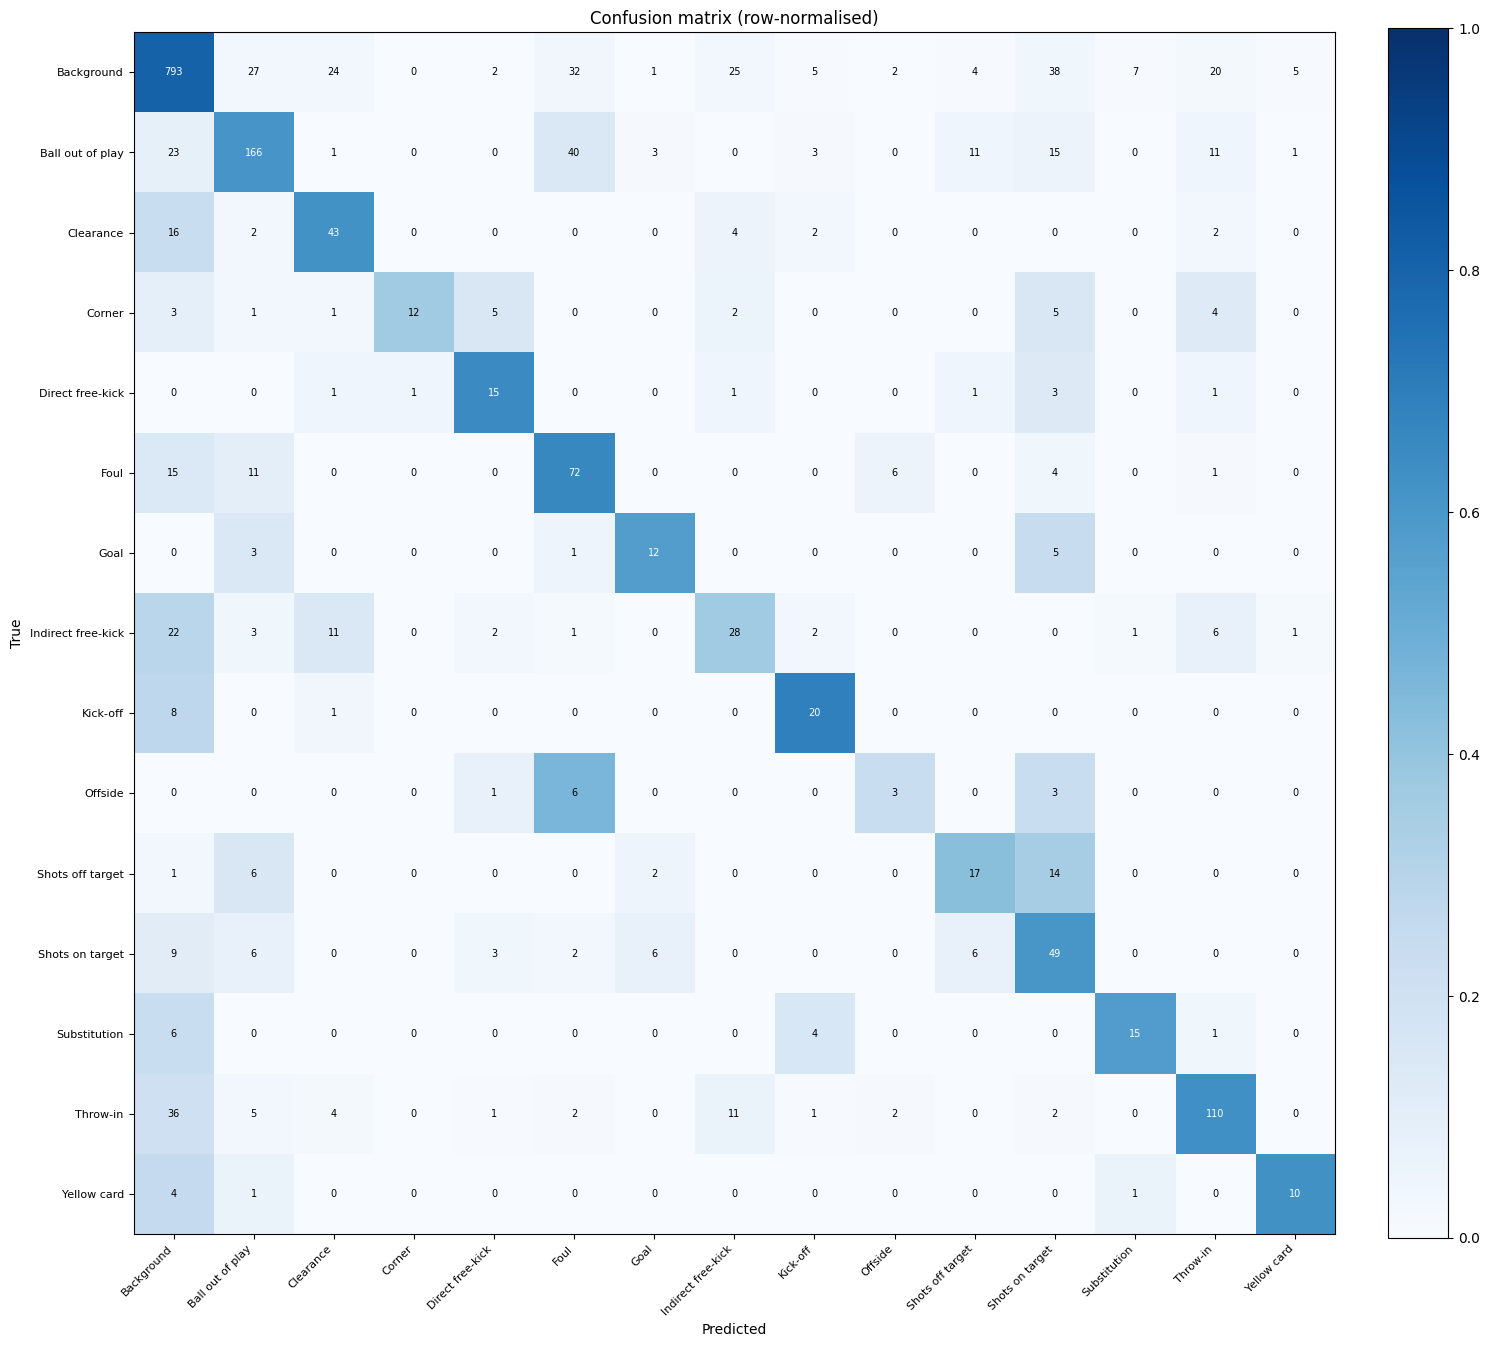

In [8]:
# Load best checkpoint and show per-class accuracy + confusion matrix
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for clips, labels in val_loader:
        preds = model(clips.to(device)).argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
present    = sorted(set(all_labels))

print(f"{'Class':<25} {'Correct':>7} {'Total':>7} {'Acc':>7}")
print("-" * 50)
for idx in present:
    mask    = all_labels == idx
    n       = mask.sum()
    correct = (all_preds[mask] == idx).sum()
    print(f"{EVENT_LABELS[idx]:<25} {correct:>7} {n:>7} {correct/n:>7.3f}")

# Confusion matrix
names  = [EVENT_LABELS[i] for i in present]
cm     = confusion_matrix(all_labels, all_preds, labels=present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)

fig, ax = plt.subplots(figsize=(max(8, len(present)), max(6, len(present))))
im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(present))); ax.set_yticks(range(len(present)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix (row-normalised)")
for i in range(len(present)):
    for j in range(len(present)):
        ax.text(j, i, f"{cm[i,j]}", ha="center", va="center",
                fontsize=7, color="white" if cm_norm[i,j] > 0.5 else "black")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## Milestone 3 — Sliding Window Spotting

In [9]:
from scipy.signal import find_peaks

def score_half(model, features, stride=1, batch=256):
    """Slide a CLIP_LEN window over features, return (T, NUM_CLASSES) softmax scores."""
    model.eval()
    T      = len(features)
    scores = np.zeros((T, NUM_CLASSES), dtype=np.float32)
    counts = np.zeros(T, dtype=np.float32)
    centers = list(range(HALF_CLIP, T - HALF_CLIP, stride))

    for i in range(0, len(centers), batch):
        chunk = centers[i:i+batch]
        x     = torch.tensor(np.stack([_extract_clip(features, c) for c in chunk])).to(device)
        with torch.no_grad():
            probs = torch.softmax(model(x), dim=1).cpu().numpy()
        for c, p in zip(chunk, probs):
            scores[c] += p
            counts[c] += 1

    # boundary frames: copy from nearest scored neighbour
    for t in range(T):
        if counts[t] == 0:
            nc = min(centers, key=lambda c: abs(c - t))
            scores[t] = scores[nc]; counts[t] = 1
    return scores / counts[:, None].clip(1)


def pick_peaks(scores, class_idx, min_distance=FPS*30, threshold=0.1):
    peaks, _ = find_peaks(scores[:, class_idx], distance=min_distance, height=threshold)
    return sorted([(int(p), float(scores[p, class_idx])) for p in peaks], key=lambda x: -x[1])


def compute_ap(predictions, gt_frames, tol_frames):
    if not gt_frames:  return float("nan")
    if not predictions: return 0.0
    matched, tp, fp = set(), [], []
    for frame, _ in sorted(predictions, key=lambda x: -x[1]):
        hit = next((i for i, g in enumerate(gt_frames) if i not in matched and abs(frame-g) <= tol_frames), None)
        if hit is not None: matched.add(hit); tp.append(1); fp.append(0)
        else:               tp.append(0);    fp.append(1)
    tp_c = np.cumsum(tp); fp_c = np.cumsum(fp)
    prec = tp_c / (tp_c + fp_c)
    rec  = tp_c / len(gt_frames)
    ap, prev_r = 0.0, 0.0
    for p, r in zip(prec, rec): ap += p * (r - prev_r); prev_r = r
    return ap


# Run on first validation game, half 1
spot_game = valid_games[0]
print(f"Scoring: {spot_game.split('/')[-1]} — half 1")
features, events = load_half(DATA_DIR, spot_game, half=1)
scores = score_half(model, features)
print(f"Score matrix: {scores.shape}")

# mAP at multiple tolerances
for tol_s in (5, 10, 30, 60):
    tol_f = tol_s * FPS
    aps   = []
    for cls_idx in range(1, NUM_CLASSES):
        gt = [e["frame"] for e in events if e["label_idx"] == cls_idx]
        ap = compute_ap(pick_peaks(scores, cls_idx), gt, tol_f)
        if not np.isnan(ap): aps.append(ap)
    print(f"  mAP@{tol_s:>2}s: {np.mean(aps):.4f}" if aps else f"  mAP@{tol_s:>2}s: n/a")

Scoring: 2015-04-11 - 19-30 Burnley 0 - 1 Arsenal — half 1
Score matrix: (5399, 18)
  mAP@ 5s: 0.3495
  mAP@10s: 0.3974
  mAP@30s: 0.5008
  mAP@60s: 0.5519


Query: 'Corner'  (ground truth: 1 events)
Rank    Time   Confidence  GT match (±60s)?
1     25:19        0.8819  no
2     23:02        0.4473  no
3     16:16        0.2013  no
4     11:44        0.1204  no


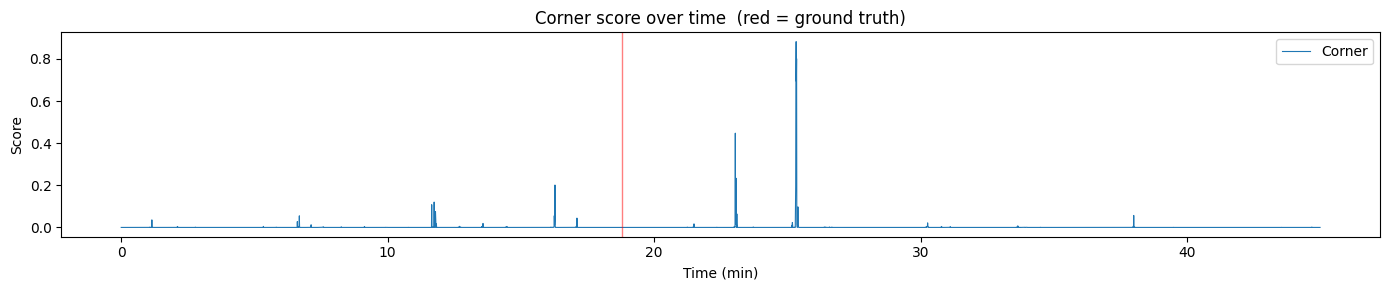

In [10]:
# Demo query: ask for a specific event class, get ranked timestamps
cls_idx   = LABEL_TO_IDX.get(QUERY_EVENT, 3)
gt_frames = [e["frame"] for e in events if e["label_idx"] == cls_idx]
preds     = pick_peaks(scores, cls_idx)

print(f"Query: '{QUERY_EVENT}'  (ground truth: {len(gt_frames)} events)")
print(f"{'Rank':<5} {'Time':>6} {'Confidence':>12}  GT match (±60s)?")
for rank, (frame, conf) in enumerate(preds[:10], 1):
    mm    = frame // (FPS * 60)
    ss    = (frame // FPS) % 60
    match = any(abs(frame - g) <= 60 * FPS for g in gt_frames)
    print(f"{rank:<5} {mm:02d}:{ss:02d}  {conf:>12.4f}  {'YES' if match else 'no'}")

# Score curve for this class
plt.figure(figsize=(14, 3))
t_axis = np.arange(len(scores)) / FPS / 60
plt.plot(t_axis, scores[:, cls_idx], linewidth=0.8, label=QUERY_EVENT)
for g in gt_frames:
    plt.axvline(g / FPS / 60, color="red", alpha=0.5, linewidth=1)
plt.xlabel("Time (min)"); plt.ylabel("Score")
plt.title(f"{QUERY_EVENT} score over time  (red = ground truth)")
plt.legend(); plt.tight_layout(); plt.show()

In [11]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB
